# Chapter 5 — Model Evaluation and Improvement

Chapter ini fokus pada cross-validation, grid search, dan metrik evaluasi.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RANDOM_STATE)

## 1. Cross-Validation

Cross-validation memberikan estimasi performa yang lebih stabil dibanding satu split saja.

In [3]:
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=5000))])
scores = cross_val_score(pipe, X_train, y_train, cv=5)
print('Skor tiap fold:', scores)
print('Rata-rata:', round(scores.mean(),4))
print('Standar deviasi:', round(scores.std(),4))

Skor tiap fold: [0.97674419 0.97647059 0.95294118 0.96470588 0.97647059]
Rata-rata: 0.9695
Standar deviasi: 0.0095


## 2. Grid Search

GridSearchCV mencoba banyak kombinasi hyperparameter dan memilih yang terbaik berdasarkan cross-validation.

In [4]:
param_grid = {'model__C':[0.01,0.1,1,10,100]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV score:', round(grid.best_score_,4))
print('Test score:', round(grid.score(X_test,y_test),4))

Best params: {'model__C': 0.1}
Best CV score: 0.9765
Test score: 0.979


## 3. Evaluasi SVM dengan Grid Search

In [5]:
svm_pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC())])
param_grid = {'svm__C':[0.1,1,10,100], 'svm__gamma':[0.001,0.01,0.1,1]}
grid_svm = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
print('Best CV score:', round(grid_svm.best_score_,4))
print('Test score:', round(grid_svm.score(X_test,y_test),4))

Best params: {'svm__C': 10, 'svm__gamma': 0.001}
Best CV score: 0.9765
Test score: 0.979


## 4. Confusion Matrix, Precision, Recall, dan F1-Score

In [6]:
y_pred = grid_svm.predict(X_test)
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Confusion Matrix:
[[51  2]
 [ 1 89]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        53
      benign       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## 5. ROC-AUC

ROC-AUC berguna untuk mengukur pemisahan kelas pada berbagai threshold.

ROC-AUC: 0.9964


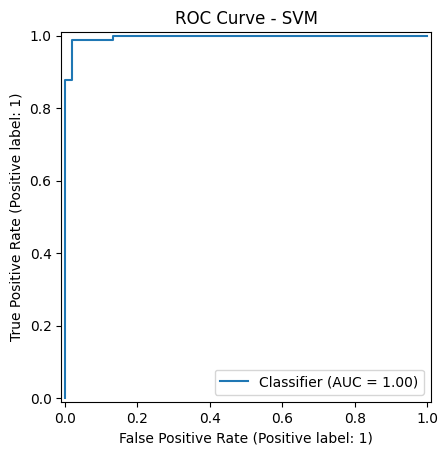

In [7]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
best_c = grid_svm.best_params_['svm__C']; best_g = grid_svm.best_params_['svm__gamma']
svm_prob = Pipeline([('scaler', StandardScaler()), ('svm', SVC(C=best_c, gamma=best_g, probability=True))])
svm_prob.fit(X_train, y_train)
proba = svm_prob.predict_proba(X_test)[:,1]
print('ROC-AUC:', round(roc_auc_score(y_test, proba),4))
RocCurveDisplay.from_predictions(y_test, proba)
plt.title('ROC Curve - SVM'); plt.show()

## Kesimpulan

Evaluasi model harus menggunakan metode dan metrik yang tepat. Pipeline dan cross-validation membantu menghindari estimasi yang terlalu optimistis.